In [1]:
import pennylane as qml

H = qml.Hamiltonian([1, 1, 0.5], [qml.PauliX(0), qml.PauliZ(1), qml.PauliX(0) @ qml.PauliX(1)])
print(H)

1 * X(0) + 1 * Z(1) + 0.5 * (X(0) @ X(1))


(<Figure size 700x300 with 1 Axes>, <Axes: >)


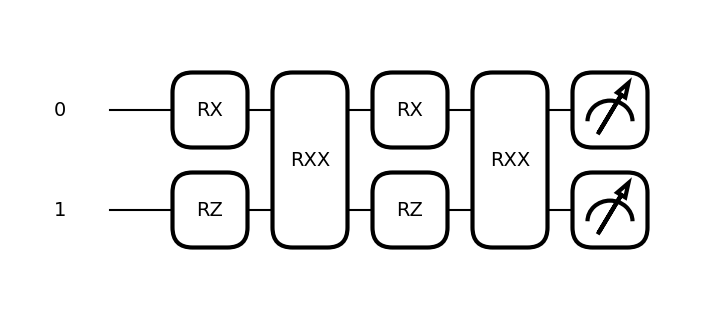

In [2]:
dev = qml.device("default.qubit", wires=2)

t = 1
n = 2


@qml.qnode(dev)
def circuit():
    qml.ApproxTimeEvolution(H, t, n)
    return [qml.expval(qml.PauliZ(i)) for i in range(2)]


print(qml.draw_mpl(circuit, level="device")())